# 13 — Coreset Comparison on the Regression Task (Task 3.2)

**Goal:** Evaluate three Stage 11 tuned models on the 100 leakage-clean coresets produced in Stage 12. Determine (a) which coreset method delivers the best model quality at each budget, (b) which models are most sensitive to coreset choice, (c) whether Stage 05's mild leakage was numerically material.

**Protocol (inherits Stages 06–11):**
- 5 rolling temporal folds, same `validation_splits.parquet`.
- Val slice = full untouched val window per fold (~407k–435k rows).
- Fresh `RobustScaler` per (method × budget × fold), fit on the coreset only. **NOT** the Stage 12 construction-time scaler.
- Three reference models with **frozen Stage 11 best configs** — no new tuning.
- CatBoost early stopping uses last 15% of the coreset's sorted indices (temporal carve).
- Metrics: MAE, RMSE, R² per target per fold.

**Experimental grid:** 5 methods × 4 budgets × 3 models × 5 folds × 2 targets = **600 metric records**.
Runtime estimate: ~70–90 min CPU.

In [1]:
import time
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.preprocessing import RobustScaler, SplineTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore', category=UserWarning)

SEED = 42

DATA_PATH   = Path('../data/processed/ethylene_methane.parquet')
SPLITS_PATH = Path('../results/tables/validation_splits.parquet')
SUBSET_DIR  = Path('../data/subsets')
TABLES_DIR  = Path('../results/tables')
FIG_DIR     = Path('../results/figures')
MEMO_PATH   = Path('../results/memos/13_coreset_comparison.md')

for d in (TABLES_DIR, FIG_DIR, MEMO_PATH.parent):
    d.mkdir(parents=True, exist_ok=True)

SENSORS = [f's{i:02d}' for i in range(1, 17)]
TARGETS = ['methane_ppm', 'ethylene_ppm']

METHODS = ['random', 'kmeans', 'fps', 'density', 'stratified']
BUDGETS = [25_000, 60_000, 120_000, 395_000]
BUDGET_LABELS = {25_000: '25k', 60_000: '60k', 120_000: '120k', 395_000: '395k'}
MODEL_NAMES = ['spline_tuned', 'extratrees_tuned', 'catboost_tuned']

plt.rcParams.update({'figure.dpi': 120, 'font.size': 9})
print(f'Methods: {METHODS}')
print(f'Budgets: {BUDGETS}')
print(f'Models:  {MODEL_NAMES}')

Methods: ['random', 'kmeans', 'fps', 'density', 'stratified']
Budgets: [25000, 60000, 120000, 395000]
Models:  ['spline_tuned', 'extratrees_tuned', 'catboost_tuned']


## 1. Load Data, Splits, Cache Val, Stage 11 Reference

In [2]:
df = pd.read_parquet(DATA_PATH, columns=SENSORS + TARGETS)
splits_df = pd.read_parquet(SPLITS_PATH)
fold_ids = sorted(int(f) for f in splits_df['fold'].unique())

# Cache full val slice per fold (loaded once, reused for all 100 cells)
val_cache = {}
for fold_id in fold_ids:
    va = splits_df[(splits_df['fold'] == fold_id) & (splits_df['split'] == 'val')].iloc[0]
    val_idx = np.arange(int(va['start_idx']), int(va['end_idx']))
    val_cache[fold_id] = {
        'X_va': df[SENSORS].iloc[val_idx].to_numpy(),
        'y_va': df[TARGETS].iloc[val_idx].to_numpy(),
        'val_start': int(va['start_idx']),
        'val_end':   int(va['end_idx']),
    }
    print(f'Fold {fold_id} val slice cached: shape={val_cache[fold_id]["X_va"].shape}')

# Stage 11 reference metrics (already on disk — do not re-compute)
stage11 = pd.read_parquet(TABLES_DIR / '11_tuning_metrics_long.parquet')
stage11_ref = stage11[stage11['model'].isin(MODEL_NAMES)].copy()
print(f'\nStage 11 reference records loaded: {len(stage11_ref)} '
      f'(expect {len(MODEL_NAMES)} models * 5 folds * 2 targets = {3*5*2})')
print('\nStage 11 reference pooled R² per model:')
print(stage11_ref.groupby('model')['r2'].mean().round(4).to_string())

Fold 1 val slice cached: shape=(407367, 16)
Fold 2 val slice cached: shape=(419449, 16)
Fold 3 val slice cached: shape=(407362, 16)
Fold 4 val slice cached: shape=(431972, 16)
Fold 5 val slice cached: shape=(435098, 16)

Stage 11 reference records loaded: 30 (expect 3 models * 5 folds * 2 targets = 30)

Stage 11 reference pooled R² per model:
model
catboost_tuned      0.5143
extratrees_tuned    0.5671
spline_tuned        0.6194


## 2. Utilities

`prepare_from_coreset(method, budget_label, fold_id)` returns scaled (X_tr, y_tr, X_va, y_va) for one cell. Scaler is fit fresh on the coreset only.

In [3]:
def load_coreset_idx(method, budget_label, fold_id):
    p = SUBSET_DIR / f'coreset_{method}_{budget_label}_fold{fold_id}.parquet'
    return pd.read_parquet(p, columns=['row_idx'])['row_idx'].to_numpy()

def prepare_from_coreset(method, budget_label, fold_id):
    coreset_idx = load_coreset_idx(method, budget_label, fold_id)

    # Sanity: coreset rows must not be inside this fold's val_range
    v_lo = val_cache[fold_id]['val_start']
    v_hi = val_cache[fold_id]['val_end']
    assert not ((coreset_idx >= v_lo) & (coreset_idx < v_hi)).any(),         f'Coreset for fold {fold_id} contains own-fold val rows'

    X_tr = df[SENSORS].iloc[coreset_idx].to_numpy()
    y_tr = df[TARGETS].iloc[coreset_idx].to_numpy()

    scaler = RobustScaler().fit(X_tr)
    X_tr_s = scaler.transform(X_tr)
    X_va_s = scaler.transform(val_cache[fold_id]['X_va'])
    y_va   = val_cache[fold_id]['y_va']

    return X_tr_s, y_tr, X_va_s, y_va, len(coreset_idx)

def temporal_carve(X, y, frac=0.15):
    n = int(len(X) * (1 - frac))
    return X[:n], y[:n], X[n:], y[n:]

print('Utilities defined.')

Utilities defined.


## 3. Frozen Stage 11 Model Factories

Configs pulled verbatim from `11_tuning_optimization.md`. Re-fits are deterministic at SEED=42.

In [4]:
def make_spline_tuned():
    return Pipeline([
        ('spline', SplineTransformer(n_knots=5, degree=3, include_bias=False)),
        ('ridge',  Ridge(alpha=1.0, random_state=SEED)),
    ])

def make_extratrees_tuned():
    return ExtraTreesRegressor(
        n_estimators=200, max_depth=10, min_samples_leaf=50,
        max_features='sqrt', n_jobs=-1, random_state=SEED,
    )

def make_catboost_tuned():
    return CatBoostRegressor(
        iterations=2000, learning_rate=0.05, depth=6, l2_leaf_reg=10,
        border_count=32, random_seed=SEED, verbose=0, thread_count=-1,
    )

# Fit-predict per model (returns y_pred shape (n_val, 2))
def fp_spline(X_tr, y_tr, X_va):
    m = make_spline_tuned()
    m.fit(X_tr, y_tr)
    return m.predict(X_va)

def fp_extratrees(X_tr, y_tr, X_va):
    m = make_extratrees_tuned()
    m.fit(X_tr, y_tr)
    return m.predict(X_va)

def fp_catboost(X_tr, y_tr, X_va):
    X_main, y_main, X_eval, y_eval = temporal_carve(X_tr, y_tr, frac=0.15)
    y_pred = np.zeros((len(X_va), 2))
    for t_idx in range(2):
        m = make_catboost_tuned()
        m.fit(X_main, y_main[:, t_idx],
              eval_set=(X_eval, y_eval[:, t_idx]),
              early_stopping_rounds=50)
        y_pred[:, t_idx] = m.predict(X_va)
    return y_pred

FIT_PREDICT = {
    'spline_tuned':    fp_spline,
    'extratrees_tuned': fp_extratrees,
    'catboost_tuned':  fp_catboost,
}

print('Model factories ready.')
for n in MODEL_NAMES:
    print(f'  {n}')

Model factories ready.
  spline_tuned
  extratrees_tuned
  catboost_tuned


## 4. Main Grid Execution

5 methods × 4 budgets × 5 folds × 3 models = 300 fits. Per-cell progress printed.

In [5]:
records = []
t_total = time.perf_counter()

for method in METHODS:
    print(f'\n=== {method} ===')
    for budget in BUDGETS:
        lbl = BUDGET_LABELS[budget]
        for fold_id in fold_ids:
            X_tr, y_tr, X_va, y_va, n_tr = prepare_from_coreset(method, lbl, fold_id)
            assert n_tr == budget, f'Mismatch: got {n_tr} expected {budget}'

            cell_t0 = time.perf_counter()
            for model_name in MODEL_NAMES:
                fp_fn = FIT_PREDICT[model_name]
                t0 = time.perf_counter()
                y_pred = fp_fn(X_tr, y_tr, X_va)
                elapsed = time.perf_counter() - t0

                for t_idx, target in enumerate(TARGETS):
                    records.append({
                        'method':       method,
                        'budget':       int(budget),
                        'budget_label': lbl,
                        'model':        model_name,
                        'fold':         int(fold_id),
                        'target':       target,
                        'mae':  float(mean_absolute_error(y_va[:, t_idx], y_pred[:, t_idx])),
                        'rmse': float(np.sqrt(mean_squared_error(y_va[:, t_idx], y_pred[:, t_idx]))),
                        'r2':   float(r2_score(y_va[:, t_idx], y_pred[:, t_idx])),
                        'seconds':      elapsed,
                        'n_train_rows': int(n_tr),
                    })
            cell_dt = time.perf_counter() - cell_t0
            print(f'  budget={lbl:<5} fold={fold_id}: {cell_dt:5.1f}s')

print(f'\nTotal grid time: {time.perf_counter()-t_total:.0f}s '
      f'({(time.perf_counter()-t_total)/60:.1f} min)')
print(f'Total records: {len(records)}  (expect {5*4*5*3*2} = 600)')
assert len(records) == 600


=== random ===
  budget=25k   fold=1:   3.8s
  budget=25k   fold=2:   2.6s
  budget=25k   fold=3:   2.9s
  budget=25k   fold=4:   3.7s
  budget=25k   fold=5:   3.0s
  budget=60k   fold=1:   4.0s
  budget=60k   fold=2:   3.3s
  budget=60k   fold=3:   4.4s
  budget=60k   fold=4:   4.3s
  budget=60k   fold=5:   3.6s
  budget=120k  fold=1:   4.5s
  budget=120k  fold=2:   4.4s
  budget=120k  fold=3:   4.7s
  budget=120k  fold=4:   5.5s
  budget=120k  fold=5:   4.2s
  budget=395k  fold=1:  10.3s
  budget=395k  fold=2:   8.8s
  budget=395k  fold=3:   9.9s
  budget=395k  fold=4:  10.8s
  budget=395k  fold=5:   9.1s

=== kmeans ===
  budget=25k   fold=1:   3.4s
  budget=25k   fold=2:   2.8s
  budget=25k   fold=3:   3.6s
  budget=25k   fold=4:   3.8s
  budget=25k   fold=5:   3.4s
  budget=60k   fold=1:   3.8s
  budget=60k   fold=2:   3.4s
  budget=60k   fold=3:   5.3s
  budget=60k   fold=4:   6.1s
  budget=60k   fold=5:   3.7s
  budget=120k  fold=1:   5.1s
  budget=120k  fold=2:   4.2s
  budget

## 5. Save Long + Summary Tables

In [6]:
long_df = pd.DataFrame(records)
long_path = TABLES_DIR / '13_coreset_comparison_long.parquet'
long_df.to_parquet(long_path, index=False)
print(f'Saved: {long_path}  ({len(long_df)} rows)')

summary = (long_df.groupby(['method', 'budget', 'budget_label', 'model', 'target'])
           [['mae', 'rmse', 'r2', 'seconds']]
           .agg(['mean', 'std']).round(4))
summary.columns = [f'{m}_{s}' for m, s in summary.columns]
summary = summary.reset_index()
summary_path = TABLES_DIR / '13_coreset_comparison_summary.parquet'
summary.to_parquet(summary_path, index=False)
print(f'Saved: {summary_path}  ({len(summary)} rows)')

# Pooled R² per (method, budget, model) — mean across folds and targets
pooled = (long_df.groupby(['method', 'budget', 'budget_label', 'model'])['r2']
          .agg(['mean', 'std']).round(4)
          .reset_index()
          .rename(columns={'mean': 'r2_mean', 'std': 'r2_std'}))
print('\nPooled R² per (method, budget, model):')
print(pooled.sort_values(['model', 'budget', 'r2_mean'], ascending=[True, True, False]).to_string(index=False))

Saved: ..\results\tables\13_coreset_comparison_long.parquet  (600 rows)
Saved: ..\results\tables\13_coreset_comparison_summary.parquet  (120 rows)

Pooled R² per (method, budget, model):
    method  budget budget_label            model  r2_mean  r2_std
       fps   25000          25k   catboost_tuned   0.5275  0.1230
stratified   25000          25k   catboost_tuned   0.5171  0.1305
    kmeans   25000          25k   catboost_tuned   0.5121  0.1358
    random   25000          25k   catboost_tuned   0.5110  0.1543
   density   25000          25k   catboost_tuned   0.4800  0.1720
       fps   60000          60k   catboost_tuned   0.5248  0.1190
    random   60000          60k   catboost_tuned   0.5145  0.1356
stratified   60000          60k   catboost_tuned   0.4988  0.1474
    kmeans   60000          60k   catboost_tuned   0.4976  0.1429
   density   60000          60k   catboost_tuned   0.4834  0.1534
    random  120000         120k   catboost_tuned   0.5134  0.1370
stratified  120000   

## 6. Analysis A — Model Sensitivity to Coreset Choice

For each (model, budget): R² range across the 5 methods. Larger range → model is more coreset-sensitive.

In [7]:
sens_rows = []
for model_name in MODEL_NAMES:
    for budget in BUDGETS:
        sub = pooled[(pooled['model']==model_name) & (pooled['budget']==budget)]
        if len(sub) == 0:
            continue
        best  = sub.loc[sub['r2_mean'].idxmax()]
        worst = sub.loc[sub['r2_mean'].idxmin()]
        sorted_sub = sub.sort_values('r2_mean', ascending=False).reset_index(drop=True)
        runner = sorted_sub.iloc[1] if len(sorted_sub) > 1 else best
        sens_rows.append({
            'model': model_name,
            'budget': int(budget),
            'budget_label': BUDGET_LABELS[budget],
            'best_method':       best['method'],
            'best_r2':           float(best['r2_mean']),
            'runner_up_method':  runner['method'],
            'runner_up_r2':      float(runner['r2_mean']),
            'worst_method':      worst['method'],
            'worst_r2':          float(worst['r2_mean']),
            'r2_range':          float(best['r2_mean'] - worst['r2_mean']),
            'best_vs_runner':    float(best['r2_mean'] - runner['r2_mean']),
        })
sens_df = pd.DataFrame(sens_rows)
sens_path = TABLES_DIR / '13_coreset_sensitivity.parquet'
sens_df.to_parquet(sens_path, index=False)
print(f'Saved: {sens_path}')
print()
print('Sensitivity table (R² range across methods):')
print(sens_df.to_string(index=False))
print()
print('Per-model mean sensitivity (averaged across 4 budgets):')
print(sens_df.groupby('model')['r2_range'].mean().round(4).to_string())

Saved: ..\results\tables\13_coreset_sensitivity.parquet

Sensitivity table (R² range across methods):
           model  budget budget_label best_method  best_r2 runner_up_method  runner_up_r2 worst_method  worst_r2  r2_range  best_vs_runner
    spline_tuned   25000          25k         fps   0.6166          density        0.6147       random    0.6082    0.0084          0.0019
    spline_tuned   60000          60k         fps   0.6200       stratified        0.6175       kmeans    0.6148    0.0052          0.0025
    spline_tuned  120000         120k         fps   0.6218          density        0.6203       kmeans    0.6167    0.0051          0.0015
    spline_tuned  395000         395k         fps   0.6221       stratified        0.6196       kmeans    0.6180    0.0041          0.0025
extratrees_tuned   25000          25k         fps   0.5780          density        0.5765   stratified    0.5664    0.0116          0.0015
extratrees_tuned   60000          60k         fps   0.5834      

## 7. Analysis B — Winning Coreset Method per (Model, Budget)

12-row table: 3 models × 4 budgets. Counts winning methods across all 12 cells.

In [8]:
winners = sens_df[['model','budget_label','best_method','best_r2',
                   'runner_up_method','runner_up_r2','best_vs_runner']]
print('Winners table:')
print(winners.to_string(index=False))
print()
print('Winner method counts across 12 cells:')
print(winners['best_method'].value_counts().to_string())
print()
print('Methods that NEVER won:')
losers = set(METHODS) - set(winners['best_method'].unique())
print(f'  {losers if losers else "(none — every method won at least once)"}')

Winners table:
           model budget_label best_method  best_r2 runner_up_method  runner_up_r2  best_vs_runner
    spline_tuned          25k         fps   0.6166          density        0.6147          0.0019
    spline_tuned          60k         fps   0.6200       stratified        0.6175          0.0025
    spline_tuned         120k         fps   0.6218          density        0.6203          0.0015
    spline_tuned         395k         fps   0.6221       stratified        0.6196          0.0025
extratrees_tuned          25k         fps   0.5780          density        0.5765          0.0015
extratrees_tuned          60k         fps   0.5834           kmeans        0.5766          0.0068
extratrees_tuned         120k         fps   0.5814           random        0.5744          0.0070
extratrees_tuned         395k      kmeans   0.5727              fps        0.5696          0.0031
  catboost_tuned          25k         fps   0.5275       stratified        0.5171          0.0104
  cat

## 8. Analysis C — Budget-Quality Curves

Per (model, method): does R² rise with budget? Where does it plateau?

In [9]:
curve_rows = []
for model_name in MODEL_NAMES:
    print(f'\n=== {model_name} ===')
    for method in METHODS:
        sub = pooled[(pooled['model']==model_name) & (pooled['method']==method)].sort_values('budget')
        if len(sub) == 0:
            continue
        r2s = sub['r2_mean'].to_numpy()
        budgets = sub['budget'].to_numpy()
        deltas = np.diff(r2s)
        monotonic = bool((deltas >= -0.005).all())  # allow tiny noise
        gain_total = float(r2s[-1] - r2s[0])
        gain_last = float(r2s[-1] - r2s[-2]) if len(r2s) >= 2 else 0.0
        curve_rows.append({
            'model': model_name, 'method': method,
            'r2_25k':  float(r2s[0]),
            'r2_60k':  float(r2s[1]),
            'r2_120k': float(r2s[2]),
            'r2_395k': float(r2s[3]),
            'total_gain':  gain_total,
            'last_step_gain': gain_last,
            'monotonic': monotonic,
        })
        print(f'  {method:>10}: R²={r2s[0]:.3f} → {r2s[1]:.3f} → {r2s[2]:.3f} → {r2s[3]:.3f}  '
              f'(total +{gain_total:.3f}, last step +{gain_last:.3f}, '
              f'{"monotonic" if monotonic else "NOT monotonic"})')

curves_df = pd.DataFrame(curve_rows)
curves_path = TABLES_DIR / '13_budget_curves.parquet'
curves_df.to_parquet(curves_path, index=False)
print(f'\nSaved: {curves_path}')


=== spline_tuned ===
      random: R²=0.608 → 0.617 → 0.620 → 0.619  (total +0.011, last step +-0.000, monotonic)
      kmeans: R²=0.610 → 0.615 → 0.617 → 0.618  (total +0.008, last step +0.001, monotonic)
         fps: R²=0.617 → 0.620 → 0.622 → 0.622  (total +0.005, last step +0.000, monotonic)
     density: R²=0.615 → 0.616 → 0.620 → 0.619  (total +0.004, last step +-0.002, monotonic)
  stratified: R²=0.613 → 0.618 → 0.620 → 0.620  (total +0.007, last step +-0.000, monotonic)

=== extratrees_tuned ===
      random: R²=0.567 → 0.575 → 0.574 → 0.567  (total +-0.000, last step +-0.008, NOT monotonic)
      kmeans: R²=0.569 → 0.577 → 0.573 → 0.573  (total +0.004, last step +-0.001, monotonic)
         fps: R²=0.578 → 0.583 → 0.581 → 0.570  (total +-0.008, last step +-0.012, NOT monotonic)
     density: R²=0.577 → 0.574 → 0.573 → 0.566  (total +-0.011, last step +-0.008, NOT monotonic)
  stratified: R²=0.566 → 0.574 → 0.573 → 0.567  (total +0.000, last step +-0.006, NOT monotonic)

=== 

## 9. Analysis D — Cross-Protocol Audit

Per-fold-stratified at budget=395k (this protocol, leakage-clean) vs Stage 11 reference (Stage 05 1M global stratified intersected, with mild leakage).

If the gap is within fold-std, Stage 05's leakage was numerically benign. If the gap is material, the Week 1 audit needs an update.

In [10]:
audit_rows = []
for model_name in MODEL_NAMES:
    # New protocol: per-fold stratified at 395k
    new_long = long_df[
        (long_df['method']=='stratified') &
        (long_df['budget']==395_000) &
        (long_df['model']==model_name)
    ]
    new_pooled_mean = float(new_long['r2'].mean())
    new_pooled_std  = float(new_long['r2'].std())

    # Stage 11 reference (already a per-fold-and-target dataframe)
    ref = stage11_ref[stage11_ref['model']==model_name]
    ref_pooled_mean = float(ref['r2'].mean())
    ref_pooled_std  = float(ref['r2'].std())

    abs_gap = abs(new_pooled_mean - ref_pooled_mean)
    pooled_combined_std = float(np.sqrt(new_pooled_std**2 + ref_pooled_std**2) / np.sqrt(2))
    within_std = abs_gap <= pooled_combined_std

    audit_rows.append({
        'model': model_name,
        'r2_new_per_fold_strat_395k':  round(new_pooled_mean, 4),
        'r2_new_std':                  round(new_pooled_std,  4),
        'r2_stage11_reference':        round(ref_pooled_mean, 4),
        'r2_stage11_ref_std':          round(ref_pooled_std,  4),
        'abs_gap':                     round(abs_gap,         4),
        'combined_std':                round(pooled_combined_std, 4),
        'gap_within_std':              bool(within_std),
    })

audit_df = pd.DataFrame(audit_rows)
audit_path = TABLES_DIR / '13_cross_protocol_audit.parquet'
audit_df.to_parquet(audit_path, index=False)
print(f'Saved: {audit_path}')
print()
print('Cross-protocol audit:')
print(audit_df.to_string(index=False))
print()
overall_verdict = 'BENIGN' if all(audit_df['gap_within_std']) else 'MATERIAL — revisit Stage 05 protocol'
print(f'Overall verdict on Stage 05 leakage: {overall_verdict}')

Saved: ..\results\tables\13_cross_protocol_audit.parquet

Cross-protocol audit:
           model  r2_new_per_fold_strat_395k  r2_new_std  r2_stage11_reference  r2_stage11_ref_std  abs_gap  combined_std  gap_within_std
    spline_tuned                      0.6196      0.0864                0.6194              0.0866   0.0001        0.0865            True
extratrees_tuned                      0.5668      0.0763                0.5671              0.0797   0.0003        0.0780            True
  catboost_tuned                      0.5028      0.1491                0.5143              0.1387   0.0115        0.1440            True

Overall verdict on Stage 05 leakage: BENIGN


## 10. Figures

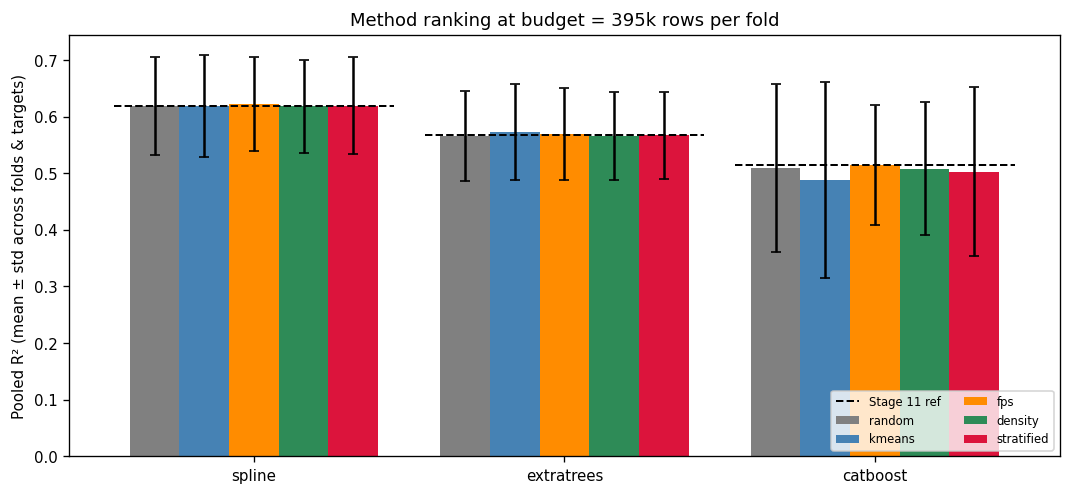

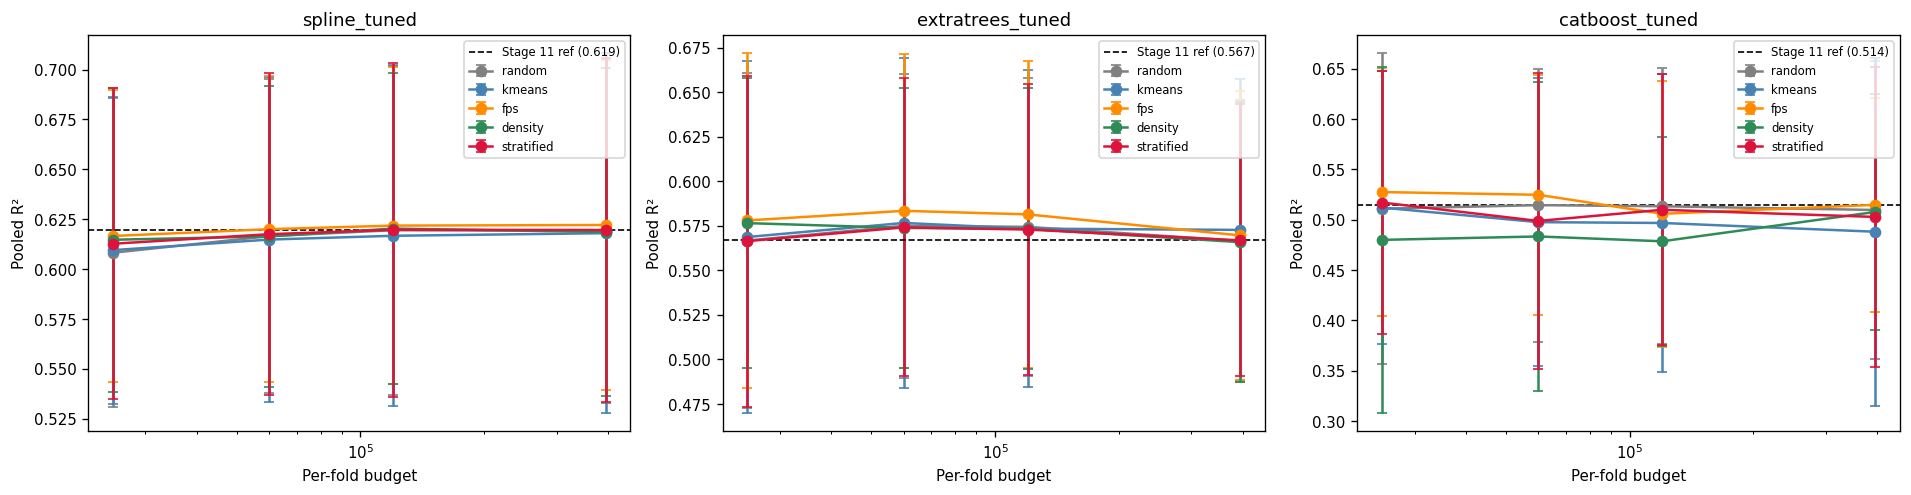

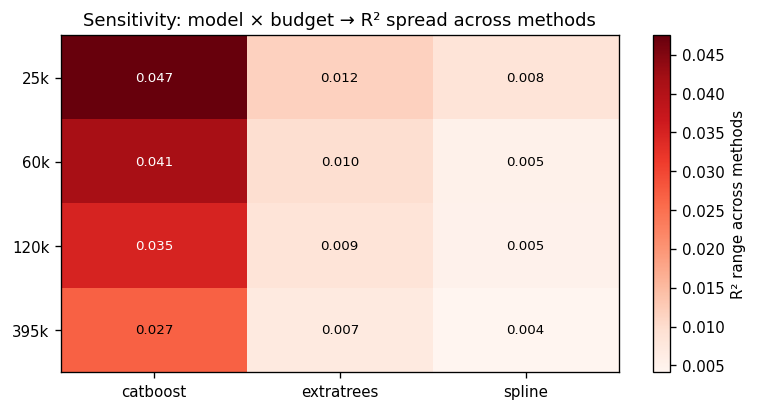

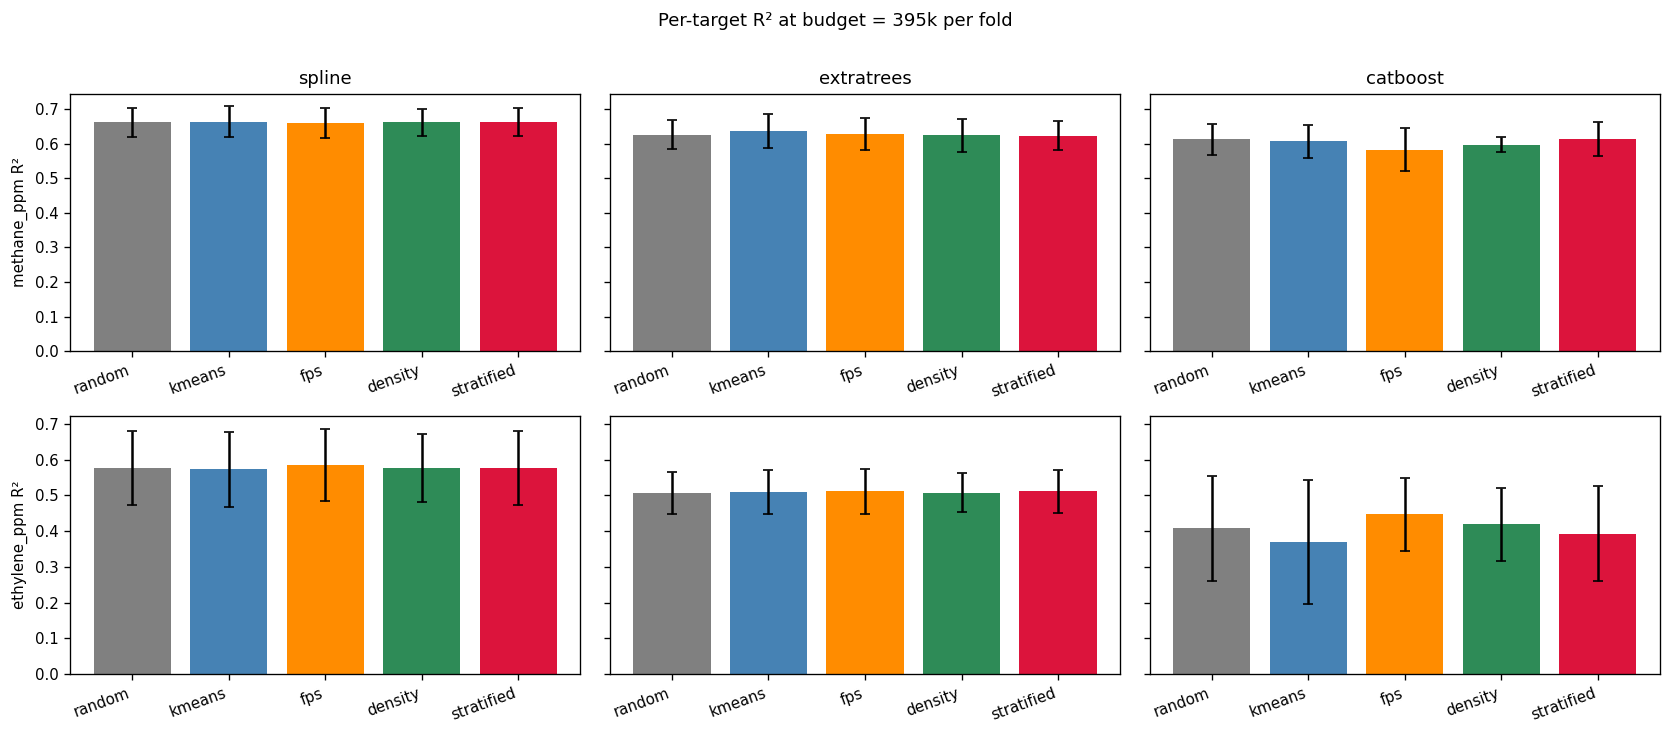

Saved 4 figures.


In [11]:
method_colors = {
    'random': 'gray', 'kmeans': 'steelblue', 'fps': 'darkorange',
    'density': 'seagreen', 'stratified': 'crimson',
}
method_order = ['random', 'kmeans', 'fps', 'density', 'stratified']

# --- Figure 1: Method ranking at budget=395k, grouped bars per model ---
fig, ax = plt.subplots(figsize=(9, 4.2))
x = np.arange(len(MODEL_NAMES))
w = 0.16
for i, m in enumerate(method_order):
    means, stds = [], []
    for model_name in MODEL_NAMES:
        sub = pooled[(pooled['model']==model_name) &
                     (pooled['method']==m) & (pooled['budget']==395_000)]
        means.append(float(sub['r2_mean'].iloc[0]) if len(sub) else 0.0)
        stds.append( float(sub['r2_std'].iloc[0])  if len(sub) else 0.0)
    ax.bar(x + (i-2)*w, means, w, yerr=stds, capsize=3,
           label=m, color=method_colors[m])
# Add Stage 11 reference as horizontal markers
for j, model_name in enumerate(MODEL_NAMES):
    ref_r2 = float(stage11_ref[stage11_ref['model']==model_name]['r2'].mean())
    ax.hlines(ref_r2, x[j]-0.45, x[j]+0.45,
              colors='black', linestyles='dashed', linewidth=1.2,
              label='Stage 11 ref' if j == 0 else None)
ax.set_xticks(x); ax.set_xticklabels([n.replace('_tuned','') for n in MODEL_NAMES])
ax.set_ylabel('Pooled R² (mean ± std across folds & targets)')
ax.set_title('Method ranking at budget = 395k rows per fold')
ax.legend(fontsize=7, loc='lower right', ncol=2)
plt.tight_layout()
plt.savefig(FIG_DIR / '13_method_ranking.png', bbox_inches='tight')
plt.show()

# --- Figure 2: Budget curves, 3 panels (one per model) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2), sharey=False)
for ax, model_name in zip(axes, MODEL_NAMES):
    for m in method_order:
        sub = pooled[(pooled['model']==model_name) &
                     (pooled['method']==m)].sort_values('budget')
        if len(sub) == 0:
            continue
        ax.errorbar(sub['budget'], sub['r2_mean'], yerr=sub['r2_std'],
                    marker='o', capsize=3, label=m, color=method_colors[m])
    ref_r2 = float(stage11_ref[stage11_ref['model']==model_name]['r2'].mean())
    ax.axhline(ref_r2, color='black', linestyle='--', linewidth=1.0,
               label=f'Stage 11 ref ({ref_r2:.3f})')
    ax.set_xscale('log')
    ax.set_xlabel('Per-fold budget')
    ax.set_ylabel('Pooled R²')
    ax.set_title(model_name)
    ax.legend(fontsize=7)
plt.tight_layout()
plt.savefig(FIG_DIR / '13_budget_curves.png', bbox_inches='tight')
plt.show()

# --- Figure 3: Sensitivity heatmap (budget × model -> R² range) ---
fig, ax = plt.subplots(figsize=(6.5, 3.5))
heat = sens_df.pivot(index='budget_label', columns='model', values='r2_range')
heat = heat.reindex(index=[BUDGET_LABELS[b] for b in BUDGETS])
im = ax.imshow(heat.values, cmap='Reds', aspect='auto')
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels([c.replace('_tuned','') for c in heat.columns])
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f'{heat.values[i,j]:.3f}', ha='center', va='center', fontsize=8,
                color='white' if heat.values[i,j] > heat.values.max()*0.6 else 'black')
plt.colorbar(im, ax=ax, label='R² range across methods')
ax.set_title('Sensitivity: model × budget → R² spread across methods')
plt.tight_layout()
plt.savefig(FIG_DIR / '13_sensitivity_heatmap.png', bbox_inches='tight')
plt.show()

# --- Figure 4: Per-target R² at budget=395k, 3 models × 2 targets = 6 subplots ---
fig, axes = plt.subplots(2, 3, figsize=(14, 6), sharey='row')
for col, model_name in enumerate(MODEL_NAMES):
    for row, target in enumerate(TARGETS):
        ax = axes[row, col]
        sub = (long_df[(long_df['model']==model_name) &
                       (long_df['budget']==395_000) &
                       (long_df['target']==target)]
               .groupby('method')['r2'].agg(['mean','std'])
               .reindex(method_order))
        means = sub['mean'].to_numpy()
        stds  = sub['std'].to_numpy()
        colors = [method_colors[m] for m in method_order]
        bars = ax.bar(np.arange(len(method_order)), means, yerr=stds,
                      capsize=3, color=colors)
        ax.set_xticks(np.arange(len(method_order)))
        ax.set_xticklabels(method_order, rotation=20, ha='right')
        if row == 0:
            ax.set_title(model_name.replace('_tuned',''))
        if col == 0:
            ax.set_ylabel(f'{target} R²')
plt.suptitle('Per-target R² at budget = 395k per fold', y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / '13_per_target_breakdown.png', bbox_inches='tight')
plt.show()

print('Saved 4 figures.')

## 11. Memo

In [12]:
def df_to_md(t):
    header = '| ' + ' | '.join(str(c) for c in t.columns) + ' |'
    sep    = '| ' + ' | '.join(['---'] * len(t.columns)) + ' |'
    rows   = ['| ' + ' | '.join(str(v) for v in row) + ' |'
              for row in t.itertuples(index=False)]
    return '\n'.join([header, sep, *rows])

best_overall = pooled.loc[pooled['r2_mean'].idxmax()]

lines = [
    '# 13 - Coreset Comparison on the Regression Task',
    '',
    '**Date:** 2026-05-28',
    f'**Dataset:** {DATA_PATH.as_posix()}',
    f'**Splits artifact:** {SPLITS_PATH.as_posix()}',
    f'**Coreset directory:** {SUBSET_DIR.as_posix()}',
    '',
    '---',
    '',
    '## Protocol',
    '- 5 rolling temporal folds, same as Stages 06-11. Val slice unchanged.',
    '- Fresh `RobustScaler` per (method, budget, fold), fit on the coreset only.',
    '- Three frozen Stage 11 models: spline_tuned, extratrees_tuned, catboost_tuned. No new tuning.',
    '- CatBoost early stopping: last 15% of each coreset (temporal carve), patience=50.',
    '- Stage 11 reference numbers loaded from `11_tuning_metrics_long.parquet` (not re-computed).',
    f'- Total records produced: {len(long_df)}.',
    '',
    f'**Best (method, budget, model) overall:** `{best_overall["method"]}` at budget {best_overall["budget_label"]} for `{best_overall["model"]}` — pooled R² = {best_overall["r2_mean"]:.4f}.',
    '',
    '## Analysis A — Sensitivity',
    '',
    df_to_md(sens_df[['model','budget_label','best_method','best_r2',
                      'worst_method','worst_r2','r2_range','best_vs_runner']].round(4)),
    '',
    f'**Per-model mean sensitivity (avg of R² range across 4 budgets):**',
    '',
    df_to_md(sens_df.groupby('model')['r2_range'].mean().round(4).reset_index()
             .rename(columns={'r2_range':'mean_r2_range_across_budgets'})),
    '',
    '## Analysis B — Winning Coreset Method',
    '',
    df_to_md(winners.round(4)),
    '',
    f'**Winner counts across 12 cells:**',
    '',
    df_to_md(winners['best_method'].value_counts()
             .rename_axis('method').reset_index(name='wins')),
    '',
    '## Analysis C — Budget-Quality Curves',
    '',
    df_to_md(curves_df[['model','method','r2_25k','r2_60k','r2_120k','r2_395k',
                        'total_gain','last_step_gain','monotonic']].round(4)),
    '',
    '## Analysis D — Cross-Protocol Audit',
    '',
    'Compares per-fold-stratified at budget=395k (this protocol, leakage-clean) against the Stage 11 reference (Stage 05 1M global stratified, intersected per fold — mild construction-pool leakage).',
    '',
    df_to_md(audit_df),
    '',
    f'**Verdict:** {"All gaps within combined fold std — Stage 05 leakage was numerically benign at the 1M budget for these models." if all(audit_df["gap_within_std"]) else "At least one gap exceeds combined fold std — Stage 05 leakage was material for at least one model. Update Week 1 table audit."}',
    '',
    '## Artifacts',
    f'- Long records: `{long_path.as_posix()}`',
    f'- Summary: `{summary_path.as_posix()}`',
    f'- Sensitivity: `{sens_path.as_posix()}`',
    f'- Budget curves: `{curves_path.as_posix()}`',
    f'- Cross-protocol audit: `{audit_path.as_posix()}`',
    f'- Figures: `{FIG_DIR.as_posix()}/13_{{method_ranking,budget_curves,sensitivity_heatmap,per_target_breakdown}}.png`',
    '',
    '## Inputs to Task 3.3 (Creative Direction Proposal)',
    '',
    '- The winning (method, budget, model) combinations indicate which coreset structure best supports each modeling regime.',
    '- The sensitivity ranking identifies whether a coreset-aware prototype should be built on a coreset-sensitive backbone (high payoff from good selection) or on a robust backbone (defensive choice).',
    '- The budget curves show whether smaller training budgets are viable for deployment, informing the compute-cost framing of the creative direction.',
    '- The cross-protocol audit confirms (or revises) whether Stage 11 baselines can be cited directly or need re-statement.',
    '',
    '## Next step',
    '',
    'Task 3.3: write the creative model direction proposal based on the analyses above.',
]

MEMO_PATH.write_text('\n'.join(lines), encoding='utf-8')
print(f'Memo saved to {MEMO_PATH}')

Memo saved to ..\results\memos\13_coreset_comparison.md
